# Experiment 1

As the dataset is a tabular data, I'm going to try bunch of experimetns using MLP

In [69]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

## Import data

Make train and test features and labels dataframes

In [70]:
DATA_DIR = "../data"

# --------------  Train Features and Labels ------------------
main_dataset = pd.read_csv(f"{DATA_DIR}/train_features.csv")
main_dataset.set_index("sig_id", inplace=True)  # set sig_id as index

# filter out control samples
main_dataset = main_dataset[main_dataset["cp_type"] == "trt_cp"]
main_dataset["cp_dose_bin"] = main_dataset["cp_dose"].map({"D1": 0, "D2": 1})  # make cp_dose a binary variable

# make metadata dataframe
metadata_cols = ["cp_type", "cp_time", "cp_dose"]
main_metadata = main_dataset[metadata_cols].copy()
# train_metadata_df.set_index("sig_id", inplace=True)  # set sig_id as index

# make train_features dataframe
feature_cols = [col for col in main_dataset.columns if col not in metadata_cols and col != "sig_id"]
main_features_df = main_dataset[feature_cols].copy()


# Make train_targets dataframe
main_targets_df = pd.read_csv(f"{DATA_DIR}/train_targets_scored.csv")
main_targets_df.set_index("sig_id", inplace=True)  # set sig_id as index

In [71]:
DATA_DIR = "../data"

# --------------  Train Features and Labels ------------------
main_dataset = pd.read_csv(f"{DATA_DIR}/train_features.csv")
main_dataset.set_index("sig_id", inplace=True)  # set sig_id as index

# filter out control samples
main_dataset = main_dataset[main_dataset["cp_type"] == "trt_cp"]
main_dataset["cp_dose_bin"] = main_dataset["cp_dose"].map({"D1": 0, "D2": 1})  # make cp_dose a binary variable

# make metadata dataframe
metadata_cols = ["cp_type", "cp_time", "cp_dose"]
main_metadata = main_dataset[metadata_cols].copy()
# train_metadata_df.set_index("sig_id", inplace=True)  # set sig_id as index

# make train_features dataframe
feature_cols = [col for col in main_dataset.columns if col not in metadata_cols and col != "sig_id"]
main_features_df = main_dataset[feature_cols].copy()


# Make train_targets dataframe
main_targets_df = pd.read_csv(f"{DATA_DIR}/train_targets_scored.csv")
main_targets_df.set_index("sig_id", inplace=True)  # set sig_id as index

# -------------- Test Features and Labels -----------------
# Make test_features dataframe
test_features_df = pd.read_csv(f"{DATA_DIR}/test_features.csv")
test_features_df.set_index("sig_id", inplace=True)  # set sig_id as index

# filter out control samples
test_features_df["cp_dose_bin"] = test_features_df["cp_dose"].map({"D1": 0, "D2": 1})  # make cp_dose a binary variable

# Make test_metadata dataframe
test_metadata_df = test_features_df[metadata_cols].copy()

# make test_features dataframe
test_features_df = test_features_df[feature_cols].copy()

## Train / Val / Dev Split

Split labeled training data into train (~60%), val (~20%), dev (~20%) using `MultilabelStratifiedKFold` (5 folds). Since each fold's held-out indices are non-overlapping and cover the full dataset, we assign fold 0 → val, fold 1 → dev, folds 2–4 → train.

In [72]:
from sklearn.decomposition import PCA

def add_pca_features(df, gene_cols, cell_cols, n_comp_g=50, n_comp_c=15):
    """
    Args:
        df: The dataframe (after scaling)
        gene_cols: list of gene feature column names
        cell_cols: list of cell feature column names
    """
    # 1. PCA for Genes
    pca_g = PCA(n_components=n_comp_g, random_state=42)
    pca_g.fit(df[gene_cols])
    g_pca = pca_g.transform(df[gene_cols])
    
    # 2. PCA for Cells
    pca_c = PCA(n_components=n_comp_c, random_state=42)
    pca_c.fit(df[cell_cols])
    c_pca = pca_c.transform(df[cell_cols])
    
    # 3. Create DataFrame and Concat
    g_cols = [f'pca_g_{i}' for i in range(n_comp_g)]
    c_cols = [f'pca_c_{i}' for i in range(n_comp_c)]
    
    pca_df = pd.concat([
        pd.DataFrame(g_pca, columns=g_cols, index=df.index),
        pd.DataFrame(c_pca, columns=c_cols, index=df.index)
    ], axis=1)
    
    return pd.concat([df, pca_df], axis=1)

In [73]:
import pandas as pd
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

# 1. Load the drug mapping
train_drug = pd.read_csv(f"{DATA_DIR}/train_drug.csv")

# 2. Merge targets with drug_id to see which drug triggers which MoA
# We merge on 'sig_id' because both tables share this common key
targets_with_drug = main_targets_df.merge(train_drug, on='sig_id')

# 3. Create a drug-level target dataframe
# We group by drug_id and use .max() so if ANY experiment for this drug is 1, the drug is 1.
drug_targets = targets_with_drug.groupby('drug_id').max().reset_index()

# 4. Perform Stratified K-Fold on the unique drugs
# This ensures rare mechanisms are distributed evenly across our 5 folds
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)
drug_targets['fold'] = -1

# X is just drug_id, y is the 206 targets (we drop non-target columns)
X_drugs = drug_targets['drug_id']
y_drugs = drug_targets.drop(['drug_id', 'sig_id'], axis=1)

# Assign fold numbers (0 to 4) to each drug
for fold, (train_idx, val_idx) in enumerate(mskf.split(X_drugs, y_drugs)):
    drug_targets.loc[val_idx, 'fold'] = fold

# 5. Map these folds back to the original main_dataset (The Robust Way)
# We first reset index so sig_id is a column, allowing us to merge
main_dataset = main_dataset.reset_index()

# Prepare the mapping dataframe: sig_id -> drug_id -> fold
fold_mapping = train_drug.merge(drug_targets[['drug_id', 'fold']], on='drug_id')

# Merge the fold column into main_dataset based on sig_id
main_dataset = main_dataset.merge(fold_mapping[['sig_id', 'fold']], on='sig_id', how='left')

# Set sig_id back as the index
main_dataset.set_index("sig_id", inplace=True)

# 6. Final verification
missing_count = main_dataset['fold'].isna().sum()
print(f"Number of rows with missing fold (should be 0): {missing_count}")

Number of rows with missing fold (should be 0): 0


In [74]:
targets_with_drug[targets_with_drug["drug_id"] == "7cbed3131"]

,sig_id,5-alpha_reductase_inhibitor,11-beta-hsd1_inhibitor,acat_inhibitor,acetylcholine_receptor_agonist,acetylcholine_receptor_antagonist,acetylcholinesterase_inhibitor,adenosine_receptor_agonist,adenosine_receptor_antagonist,adenylyl_cyclase_activator,...,trpv_agonist,trpv_antagonist,tubulin_inhibitor,tyrosine_kinase_inhibitor,ubiquitin_specific_protease_inhibitor,vegfr_inhibitor,vitamin_b,vitamin_d_receptor_agonist,wnt_inhibitor,drug_id
4,id_001626bd3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7cbed3131
3812,id_28bedaf41,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7cbed3131
11289,id_795f4f2fe,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7cbed3131
14935,id_a09620969,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7cbed3131
16950,id_b661a670c,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7cbed3131
19455,id_d0c8d6d38,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7cbed3131


## PyTorch Dataset and DataLoaders

In [75]:
class MoADataset(Dataset):
    def __init__(self, features, targets=None):
        """
        features: DataFrame or numpy array of your 872+ input features
        targets:  DataFrame or numpy array of your 206 MoA labels (optional for test set)
        """
        # Convert pandas to float32 tensors (PyTorch default is float32)
        self.features = torch.tensor(features.values, dtype=torch.float32)
        
        # Handle the test set case where targets might be None
        if targets is not None:
            self.targets = torch.tensor(targets.values, dtype=torch.float32)
        else:
            self.targets = None

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        # Return features and targets as a tuple
        if self.targets is not None:
            return self.features[idx], self.targets[idx]
        else:
            # Just return features if this is a test set
            return self.features[idx]

In [93]:
from sklearn.preprocessing import QuantileTransformer
import pandas as pd

def prepare_data(X_train, X_val, X_test=None):
    print("====="* 10)
    print(f"Before prepare_data: X_train: {X_train.shape} | X_val: {X_val.shape}")
    
    # 1. Capture columns BEFORE scaling
    cols = X_train.columns
    
    # 2. Initialize the QuantileTransformer
    # We use 'normal' output to squash outliers and center the data
    qt = QuantileTransformer(n_quantiles=100, random_state=42, output_distribution='normal')
    
    # 3. Fit ONLY on training data
    qt.fit(X_train)
    
    # 4. Transform all sets (and convert directly back to DataFrame with original columns)
    X_train_transformed = pd.DataFrame(qt.transform(X_train), columns=cols, index=X_train.index)
    X_val_transformed   = pd.DataFrame(qt.transform(X_val),   columns=cols, index=X_val.index)
    
    if X_test is not None:
        X_test_transformed = pd.DataFrame(qt.transform(X_test), columns=cols, index=X_test.index)
    else:
        X_test_transformed = None
        
    print(f"After QT: X_train: {X_train_transformed.shape} | X_val: {X_val_transformed.shape}")
        
    # Add PCA feature
    gene_cols = list(X_train.filter(regex="^g-").columns)
    cell_cols = list(X_train.filter(regex="^c-").columns)
    X_train = add_pca_features(X_train_transformed, gene_cols, cell_cols)
    X_val = add_pca_features(X_val_transformed, gene_cols, cell_cols)
    
    print(f"After PCA: X_train: {X_train.shape} | X_val: {X_val.shape}")
    
    return X_train, X_val, X_test_transformed

In [77]:
import matplotlib.pyplot as plt

def plot_fold_results(train_losses, val_losses, val_f1s, val_accs, fold_id):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot Loss
    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Val Loss')
    ax1.set_title(f'Fold {fold_id} Loss Trend')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Plot F1 Score
    ax2.plot(val_f1s, label='Val F1 Score', color='green')
    ax2.set_title(f'Fold {fold_id} F1 Trend')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('F1 Score')
    ax2.legend()
    ax2.grid(True)
    
    # Plot Acc Score
    ax3.plot(val_accs, label='Val Acc Score', color='red')
    ax3.set_title(f'Fold {fold_id} Acc Trend')
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('Acc Score')
    ax3.legend()
    ax3.grid(True)
    
    plt.show()
    fig.savefig(f"score_loss_fold{fold_id}.png")

## Pytorch Model

In [98]:
import torch.nn as nn

class MoAModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        # Layer 1
        self.fc1 = nn.Linear(input_dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.dropout1 = nn.Dropout(0.4)
        
        # Layer 2
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(0.4)
        
        # Output Layer
        self.fc3 = nn.Linear(256, output_dim)
        # NO SIGMOID HERE!
    
    def forward(self, x):
        # Block 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout1(x)
        
        # Block 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout2(x)
        
        # Output
        x = self.fc3(x)
        return x

## Train Model

In [100]:
import torch.nn as nn

def train_one_epoch(model, loader, optimizer, criterion, device, label_smoothing:int =None):
    model.train()
    total_loss = 0
    
    for features, targets in loader:
        features, targets = features.to(device), targets.to(device)
        
        if label_smoothing:
            targets = targets * (1 - label_smoothing) + 0.5 * label_smoothing
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(features)
        
        # Binary Cross Entropy with Logits is the standard for MoA
        loss = criterion(outputs, targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    return total_loss / len(loader)

In [89]:
from sklearn.metrics import f1_score, accuracy_score

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for features, targets in loader:
            features, targets = features.to(device), targets.to(device)
            outputs = model(features)
            
            loss = criterion(outputs, targets)
            total_loss += loss.item()
            
            # Store raw probabilities and targets
            all_preds.append(torch.sigmoid(outputs).cpu().numpy())
            all_targets.append(targets.cpu().numpy())
            
    # Calculate F1 Score
    # We round probs to 0 or 1 for F1 calculation
    preds_np = np.concatenate(all_preds)
    targets_np = np.concatenate(all_targets)
    preds_binary = (preds_np > 0.7).astype(int)
    
    # average='samples' is great for multi-label problems
    val_f1 = f1_score(targets_np, preds_binary, average='samples', zero_division=np.nan)
    val_acc = accuracy_score(targets_np, preds_binary)
    
    return total_loss / len(loader), val_f1, val_acc

Training Loop

In [81]:
print(f"Features index name: {main_features_df.index.name}")

Features index name: sig_id


In [82]:
# Check exactly what is inside your fold column
print("Fold distribution:")
print(main_dataset['fold'].value_counts(dropna=False))

# Check for rows that are not assigned to a valid fold (0-4)
invalid_folds = main_dataset[~main_dataset['fold'].isin([0, 1, 2, 3, 4])]
print(f"\nNumber of unassigned or invalid rows: {len(invalid_folds)}")

Fold distribution:
fold
2    4900
3    4366
4    4320
1    4199
0    4163
Name: count, dtype: int64

Number of unassigned or invalid rows: 0



--- TRAINING FOLD 0 on cuda ---
Before prepare_data: X_train: (17785, 873) | X_val: (4163, 873)
After QT: X_train: (17785, 873) | X_val: (4163, 873)
After PCA: X_train: (17785, 938) | X_val: (4163, 938)


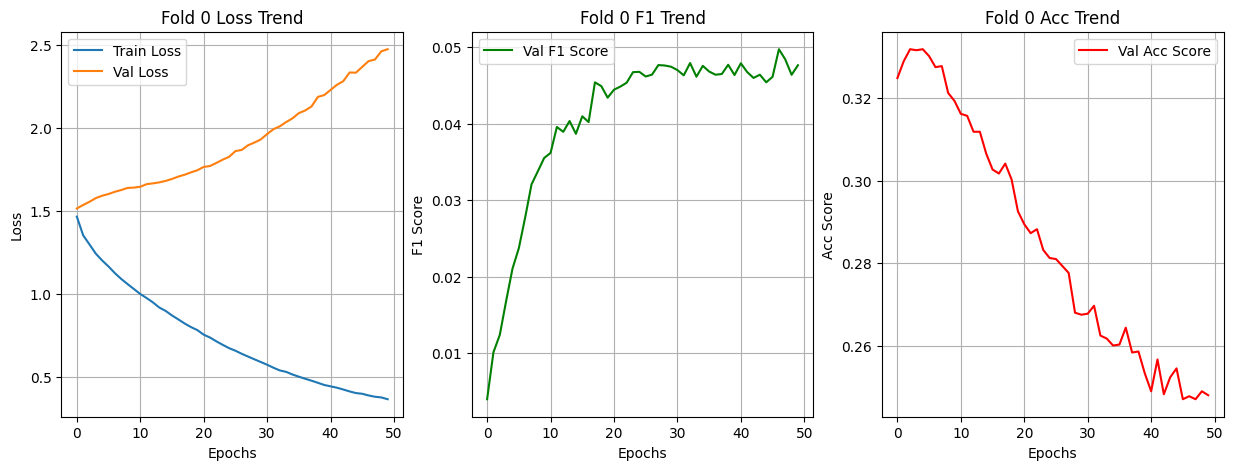


Final CV Val Loss: 1.51453


In [103]:
# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FOLDS = 5

# This list will store the validation loss of each fold to calculate the final CV score
cv_scores = []
fold_histories = [] # To store metrics for all folds

for fold_id in range(FOLDS):
    print(f"\n--- TRAINING FOLD {fold_id} on {DEVICE} ---")
    # ADD THESE LINES
    
    train_losses, val_losses, val_f1s, val_accs = [], [], [], []
    
    # 1. Split data based on the 'fold' column we created
    # Training: All rows NOT in the current fold
    # Validation: Only the rows IN the current fold
    train_idx = main_dataset[main_dataset['fold'] != fold_id].index
    val_idx   = main_dataset[main_dataset['fold'] == fold_id].index
        
    X_train, y_train = main_features_df.loc[train_idx], main_targets_df.loc[train_idx]
    X_val,   y_val   = main_features_df.loc[val_idx],   main_targets_df.loc[val_idx]
    
    # Quantile Transforming: Gene and cell data often have outliers. Using a Quantile Transformer 
    # is to map features to a normal distribution.
    X_train, X_val, _ = prepare_data(X_train, X_val)
    
    with open("X_val_colmns.txt", 'w') as xvc:
        for i in list(X_val.columns):
            xvc.write(f"{i}\n")
    
    # 2. DataLoaders for this specific fold
    train_loader = DataLoader(MoADataset(X_train, y_train), batch_size=128, shuffle=True)
    val_loader   = DataLoader(MoADataset(X_val, y_val),   batch_size=128, shuffle=False)
    
    # Weighted loss settings (This tells the model: "When you get a positive class wrong,
    # it is X times more expensive than getting a negative class wrong.")
    # 1. Calculate weights from your target training set
    counts_pos = main_targets_df.sum(axis=0)
    counts_neg = len(main_targets_df) - counts_pos
    # Calculate ratio (Add a small epsilon to avoid division by zero)
    pos_weights = counts_neg / (counts_pos + 1e-6)
    # 2. Convert to Tensor
    pos_weights = torch.tensor(pos_weights.values, dtype=torch.float32).to(DEVICE)
    
    # 3. Initialize Model, Optimizer, and Loss (MUST RESET EVERY FOLD)
    model = MoAModel(input_dim=X_train.shape[1], output_dim=206).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weights)
    
    # 4. The Training Loop for this Fold
    best_loss = np.inf
    
    # Early Stopping logic
    best_val_loss = float('inf')
    patience = 5  # Stop if no improvement for 5 epochs
    epochs_no_improve = 0
    
    for epoch in range(50):
        # 1. Train
        loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, label_smoothing=None)
        train_losses.append(loss)
        
        # 2. Validate
        v_loss, v_f1, v_acc = validate_one_epoch(model, val_loader, criterion, DEVICE)
        val_losses.append(v_loss)
        val_f1s.append(v_f1)
        val_accs.append(v_acc)
        
        # 3. Save Best
        if v_loss < best_loss:
            best_loss = v_loss
            torch.save(model.state_dict(), 'best_model.pth')
            epochs_no_improve = 0
        # else:
        #     epochs_no_improve += 1
        #     if epochs_no_improve >= patience:
        #         print("Early stopping triggered!")
        #         break
            
    # Store history for global analysis
    fold_histories.append({'train': train_losses, 'val_loss': val_losses, 'val_f1': val_f1s})
    # Plot after the fold is done
    plot_fold_results(train_losses, val_losses, val_f1s, val_accs, fold_id)
            
    cv_scores.append(best_loss)
    
    break

print(f"\nFinal CV Val Loss: {np.mean(cv_scores):.5f}")

In [84]:
# Check exactly what is inside your fold column
print("Fold distribution:")
print(main_dataset['fold'].value_counts(dropna=False))

# Check for rows that are not assigned to a valid fold (0-4)
invalid_folds = main_dataset[~main_dataset['fold'].isin([0, 1, 2, 3, 4])]
print(f"\nNumber of unassigned or invalid rows: {len(invalid_folds)}")

Fold distribution:
fold
2    4900
3    4366
4    4320
1    4199
0    4163
Name: count, dtype: int64

Number of unassigned or invalid rows: 0
